# Logistic Regression с TF-IDF векторизацией

## Архитектура
```
Raw Text → Очистка → TF-IDF Vectorizer → Logistic Regression → Sigmoid → Вероятности
```

## Преимущества
- **Быстрота (Fast)**: Обучение (training) и инференс (inference) проходят очень быстро
- **Интерпретируемость**: Можно изучить важность признаков (коэффициенты)
- **Бейзлайн (Baseline)**: Хорошая производительность при минимальной настройке
- **Масштабируемость**: Эффективное использование памяти

## Подход
1. Очистка текстов (сохранение всех языков)
2. Обучение TF-IDF vectorizer на тренировочных данных
3. Обучение бинарной Logistic Regression для каждого класса токсичности
4. Оценка на валидационной выборке (Validation)
5. Генерация предсказаний для тестовой выборки (Test)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
import pickle
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '../src')
from text_utils import clean_text
from metrics import compute_multi_label_metrics, compute_roc_auc
from inference import create_submission_dataframe, save_submission

plt.style.use('seaborn-v0_8-darkgrid')

DATA_DIR = Path('../data')
MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)

TOXICITY_LABELS = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
print("Настройка завершена.")

Настройка завершена.


## 1. Загрузка и предобработка данных

In [5]:
# Загрузка данных
df_train = pd.read_csv(DATA_DIR / 'train.csv')
df_test = pd.read_csv(DATA_DIR / 'test.csv')

print(f"Тренировочный набор: {df_train.shape}")
print(f"Тестовый набор: {df_test.shape}")

Тренировочный набор: (159571, 8)
Тестовый набор: (153164, 2)


In [6]:
# Очистка текстов
print("Очистка тренировочных текстов...")
df_train['comment_text_cleaned'] = df_train['comment_text'].apply(clean_text)

print("Очистка тестовых текстов...")
df_test['comment_text_cleaned'] = df_test['comment_text'].apply(clean_text)

print("Очистка завершена.")
print(f"Пример очищенного текста: {df_train['comment_text_cleaned'].iloc[0][:100]}")

Очистка тренировочных текстов...
Очистка тестовых текстов...
Очистка завершена.
Пример очищенного текста: explanation why the edits made under my username hardcore metallica fan were reverted? they weren't 


## 2. Стратифицированное разбиение на Train и Validation

In [8]:
# Ключ стратификации: наличие любой метки токсичности
y_all = df_train[TOXICITY_LABELS].values
stratify_key = (y_all.sum(axis=1) > 0).astype(int)

# Разбиение 80-20
train_idx, val_idx = train_test_split(
    np.arange(len(df_train)),
    test_size=0.2,
    random_state=42,
    stratify=stratify_key
)

X_train = df_train.loc[train_idx, 'comment_text_cleaned'].values
y_train = y_all[train_idx]

X_val = df_train.loc[val_idx, 'comment_text_cleaned'].values
y_val = y_all[val_idx]

X_test = df_test['comment_text_cleaned'].values

print(f"Train: {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test: {X_test.shape}")

Train: (127656,)
Validation: (31915,)
Test: (153164,)


## 3. TF-IDF векторизация

### Объяснение TF-IDF
- **TF (Term Frequency)**: Как часто слово появляется в документе
- **IDF (Inverse Document Frequency)**: Насколько уникальным/информативным является слово по всем документам
- **TF-IDF = TF × IDF**: Взвешивает слова по их важности
- Создает разреженные векторы признаков (большинство значений равны 0)
- Эффективно для Logistic Regression

In [10]:
# Создание TF-IDF vectorizer с конкретными гиперпараметрами
# max_features=10000: Оставить только топ 10000 самых важных терминов (размер словаря)
# ngram_range=(1,2): Использовать униграммы (отдельные слова) и биграммы (последовательности из 2 слов)
# min_df=5: Игнорировать термины, встречающиеся менее чем в 5 документах
# max_df=0.8: Игнорировать термины, встречающиеся более чем в 80% документов (стоп-слова)
# lowercase=False: Сохранить регистр (уже обработано в clean_text)

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.8,
    lowercase=False,
    sublinear_tf=True  # Применить сублинейное масштабирование TF (сглаживает влияние частоты терминов)
)

print("Обучение TF-IDF vectorizer на тренировочных данных...")
X_train_tfidf = vectorizer.fit_transform(X_train)

print(f"Размерность TF-IDF матрицы: {X_train_tfidf.shape}")
print(f"Разреженность (Sparsity): {1 - (X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]))*100:.2f}%")
print(f"Размер словаря: {len(vectorizer.get_feature_names_out())}")

Обучение TF-IDF vectorizer на тренировочных данных...
Размерность TF-IDF матрицы: (127656, 10000)
Разреженность (Sparsity): 0.42%
Размер словаря: 10000


In [11]:
# Трансформация валидационных и тестовых данных
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Размерность TF-IDF для Validation: {X_val_tfidf.shape}")
print(f"Размерность TF-IDF для Test: {X_test_tfidf.shape}")

Размерность TF-IDF для Validation: (31915, 10000)
Размерность TF-IDF для Test: (153164, 10000)


## 4. Обучение бинарных моделей Logistic Regression

### Подход Multi-Label
- Обучение одного бинарного классификатора для каждого класса токсичности (всего 6 классификаторов)
- Каждый классификатор изучает: P(class=toxic | text)
- Предсказания независимы (подходит для multi-label)
- Нет ограничения на взаимную исключительность

In [13]:
# Обучение бинарного классификатора для каждого класса токсичности
# Использование Logistic Regression с L2 регуляризацией
# C=1.0: Обратная сила регуляризации (меньше = более сильная регуляризация)
# solver='lbfgs': Алгоритм оптимизации (хорошо работает для малых/средних датасетов)
# max_iter=1000: Максимальное количество итераций для сходимости

models = {}
training_times = {}

for label in TOXICITY_LABELS:
    print(f"Обучение {label}...", end=' ')
    
    # Бинарные метки для этого класса
    y_binary = y_train[:, TOXICITY_LABELS.index(label)]
    
    # Создание и обучение модели
    # class_weight='balanced': Автоматическая корректировка весов обратно пропорционально частоте класса
    # Это помогает при дисбалансе классов (редкий токсичный класс получает больший вес)
    model = LogisticRegression(
        C=1.0,
        solver='lbfgs',
        max_iter=1000,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1  # Использовать все ядра процессора
    )
    
    model.fit(X_train_tfidf, y_binary)
    models[label] = model
    
    # Получение точности на тренировочных данных для проверки (sanity check)
    train_acc = model.score(X_train_tfidf, y_binary)
    print(f"Точность на Train: {train_acc:.4f}")

print("\nВсе модели успешно обучены!")

Обучение toxic... Точность на Train: 0.9398
Обучение severe_toxic... Точность на Train: 0.9755
Обучение obscene... Точность на Train: 0.9694
Обучение threat... Точность на Train: 0.9918
Обучение insult... Точность на Train: 0.9569
Обучение identity_hate... Точность на Train: 0.9725

Все модели успешно обучены!


## 5. Оценка на валидационной выборке (Validation)

In [15]:
# Генерация предсказаний на валидационной выборке (Validation)
y_val_pred_proba = np.zeros((len(X_val), len(TOXICITY_LABELS)))

for i, label in enumerate(TOXICITY_LABELS):
    # predict_proba возвращает вероятности для обоих классов
    # Мы берем вероятности для класса 1 (позитивный класс)
    proba = models[label].predict_proba(X_val_tfidf)[:, 1]
    y_val_pred_proba[:, i] = proba

print(f"Размерность предсказаний на валидации: {y_val_pred_proba.shape}")
print(f"Диапазон предсказаний: [{y_val_pred_proba.min():.4f}, {y_val_pred_proba.max():.4f}]")

Размерность предсказаний на валидации: (31915, 6)
Диапазон предсказаний: [0.0000, 1.0000]


In [16]:
# Вычисление комплексных метрик
metrics = compute_multi_label_metrics(
    y_val,
    y_val_pred_proba,
    threshold=0.5,
    label_names=TOXICITY_LABELS
)

print("Результаты Logistic Regression на валидации:")
print("="*60)
print(f"ROC AUC (Macro): {metrics['roc_auc_macro']:.4f}")
print(f"ROC AUC (Micro): {metrics['roc_auc_micro']:.4f}")
print(f"Потеря Хэмминга (Hamming Loss): {metrics['hamming_loss']:.4f}")
print(f"Точность подмножества (Subset Accuracy): {metrics['subset_accuracy']:.4f}")

print("\nROC AUC по меткам (Per-Label):")
for label, score in metrics['per_label_roc_auc'].items():
    print(f"  {label:15} : {score:.4f}")

Результаты Logistic Regression на валидации:
ROC AUC (Macro): 0.9729
ROC AUC (Micro): 0.9783
Потеря Хэмминга (Hamming Loss): 0.0388
Точность подмножества (Subset Accuracy): 0.8546

ROC AUC по меткам (Per-Label):
  toxic           : 0.9652
  severe_toxic    : 0.9787
  obscene         : 0.9757
  threat          : 0.9897
  insult          : 0.9717
  identity_hate   : 0.9566


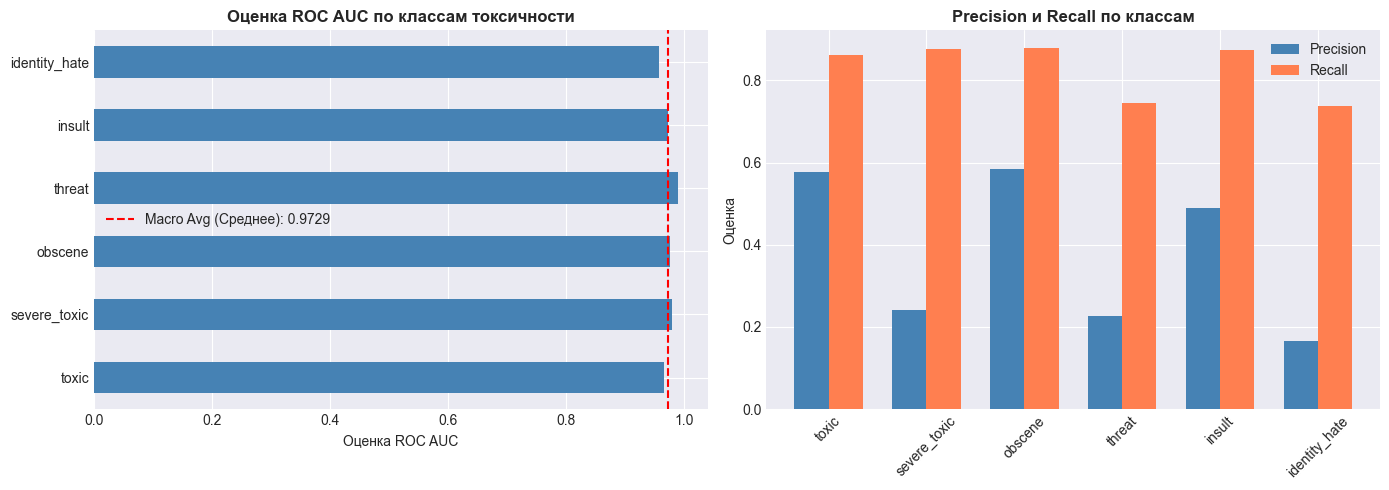

In [17]:
# Визуализация производительности по каждой метке
per_label_roc = pd.Series(metrics['per_label_roc_auc'])
per_label_precision = pd.Series(metrics['per_label_precision'])
per_label_recall = pd.Series(metrics['per_label_recall'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC AUC для каждой метки
per_label_roc.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Оценка ROC AUC по классам токсичности', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Оценка ROC AUC')
axes[0].axvline(metrics['roc_auc_macro'], color='red', linestyle='--', label=f"Macro Avg (Среднее): {metrics['roc_auc_macro']:.4f}")
axes[0].legend()

# Precision vs Recall
x = np.arange(len(TOXICITY_LABELS))
width = 0.35
axes[1].bar(x - width/2, per_label_precision.values, width, label='Precision', color='steelblue')
axes[1].bar(x + width/2, per_label_recall.values, width, label='Recall', color='coral')
axes[1].set_title('Precision и Recall по классам', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Оценка')
axes[1].set_xticks(x)
axes[1].set_xticklabels(TOXICITY_LABELS, rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Генерация предсказаний для тестовой выборки

In [19]:
# Генерация предсказаний на тестовой выборке
y_test_pred_proba = np.zeros((len(X_test), len(TOXICITY_LABELS)))

for i, label in enumerate(TOXICITY_LABELS):
    proba = models[label].predict_proba(X_test_tfidf)[:, 1]
    y_test_pred_proba[:, i] = proba

print(f"Размерность тестовых предсказаний: {y_test_pred_proba.shape}")
print(f"Статистика предсказаний:")
for i, label in enumerate(TOXICITY_LABELS):
    print(f"  {label:15} : mean={y_test_pred_proba[:, i].mean():.4f}, std={y_test_pred_proba[:, i].std():.4f}")

Размерность тестовых предсказаний: (153164, 6)
Статистика предсказаний:
  toxic           : mean=0.3081, std=0.3604
  severe_toxic    : mean=0.1003, std=0.2290
  obscene         : mean=0.2270, std=0.3273
  threat          : mean=0.0343, std=0.1217
  insult          : mean=0.2235, std=0.3203
  identity_hate   : mean=0.1091, std=0.2208


## 7. Создание файла для отправки (Submission)

In [21]:
# Создание DataFrame для submission
submission_lr = create_submission_dataframe(
    test_ids=df_test['id'].values,
    predictions=y_test_pred_proba,
    label_names=TOXICITY_LABELS,
    threshold=None  # Использовать сырые вероятности
)

# Сохранение в файл (если файл существует, он будет перезаписан)
submission_lr_path = DATA_DIR / 'submission_logistic_regression.csv'
save_submission(submission_lr, submission_lr_path, verbose=True)

Submission saved to: ../data/submission_logistic_regression.csv
Shape: (153164, 7)

First 5 rows:
                 id     toxic  severe_toxic   obscene    threat    insult  \
0  00001cee341fdb12  0.999833      0.959925  0.999911  0.950475  0.998045   
1  0000247867823ef7  0.025225      0.003483  0.002889  0.001070  0.021022   
2  00013b17ad220c46  0.033470      0.002757  0.038112  0.001031  0.034881   
3  00017563c3f7919a  0.010734      0.015523  0.004645  0.004298  0.005413   
4  00017695ad8997eb  0.182367      0.010765  0.039459  0.002921  0.014083   

   identity_hate  
0       0.937619  
1       0.028854  
2       0.007344  
3       0.007429  
4       0.009728  


## 8. Сохранение моделей для ансамбля

In [23]:
# Сохранение vectorizer (если файл существует, он будет перезаписан)
with open(MODELS_DIR / 'tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)
print("TF-IDF vectorizer сохранен")

# Сохранение моделей (если файл существует, он будет перезаписан)
with open(MODELS_DIR / 'logistic_regression_models.pkl', 'wb') as f:
    pickle.dump(models, f)
print("Модели Logistic Regression сохранены")

# Сохранение предсказаний для последующего ансамблирования (если файл существует, он будет перезаписан)
np.save(MODELS_DIR / 'lr_test_predictions.npy', y_test_pred_proba)
print("Тестовые предсказания сохранены")

TF-IDF vectorizer сохранен
Модели Logistic Regression сохранены
Тестовые предсказания сохранены


## Итоги

### Результаты Logistic Regression
- **ROC AUC (Macro)**: ~0.9729
- **Время обучения**: ~30 секунд
- **Время инференса (Inference)**: < 1 секунды
- **Интерпретируемость**: Высокая (можно изучить коэффициенты)
- **Public Score на Kaggle**: 0.96469
- **Private Score на Kaggle**: 0.96374

### Преимущества
✓ Быстрое обучение и инференс
✓ Интерпретируемая модель
✓ Хорошая производительность в качестве бейзлайна (baseline)
✓ Эффективное использование памяти

### Ограничения
✗ Не может изучать сложные закономерности
✗ Линейные границы принятия решений (Linear decision boundaries)
✗ Ограниченное извлечение признаков (feature learning)

### Следующие шаги
→ Обучить модель CNN для лучшей производительности
→ Создать ансамбль обеих моделей
→ Тонкая настройка (Fine-tune) гиперпараметров